In [1]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
%load_ext autoreload
%autoreload 2
import numpy as np
import scipy as sp
import pandas as pd
import networkx as nx
import random
import matplotlib.pyplot as plt
# import warnings filter
from warnings import simplefilter
# ignore all future warnings
simplefilter(action='ignore', category=FutureWarning)
from IPython.core.display import HTML
HTML('<style>.container { width:95% !important; }</style><style>.output_png {display: table-cell;text-align: center;vertical-align: middle;}</style>')

In [2]:
import torch
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA version built with PyTorch: {torch.version.cuda}")
    print(f"Number of GPUs: {torch.cuda.device_count()}")
    print(f"Current GPU name: {torch.cuda.get_device_name(torch.cuda.current_device())}")
else:
    print("PyTorch was not built with CUDA support or CUDA is not configured correctly.")


PyTorch version: 2.7.1
CUDA available: False
PyTorch was not built with CUDA support or CUDA is not configured correctly.


In [3]:
import warnings
warnings.filterwarnings("ignore", message=".*PossibleUserWarning.*")
warnings.filterwarnings("ignore", message=".*does not have many workers.*")
warnings.filterwarnings("ignore", message=".*to enable TensorBoard support.*")

import os, sys
sys.stderr = open(os.devnull, 'w')

In [4]:
import sys
from pathlib import Path

_cwd = Path().resolve()
_candidates = (_cwd, _cwd.parent)
for _root in _candidates:
    if (_root / 'node_diffusion').exists():
        if str(_root) not in sys.path:
            sys.path.insert(0, str(_root))
        break
else:
    raise ModuleNotFoundError("Could not locate 'node_diffusion' package; adjust sys.path.")

del _cwd, _candidates, _root


# Code

In [5]:
def binary_classification_dataset_generation(
    graphs, 
    targets, 
    decompositional_encoder_decoder,
    n_instances = 64,
    C = 0.01,
    creativity = 0.75,
    verbose=True):

    confidence = 1 - creativity
    t_start=0.5-0.5*confidence,
    t_end=0.5+0.5*confidence,

    X = decompositional_encoder_decoder.graph_vectorizer.transform(graphs)
    y = np.array(targets)

    pairs = find_margin_sv_pairs(X, y, C=C)
    if verbose: print(f"Found {len(pairs)} pairs with C:{C:.1e}")

    n_iter = n_instances//(2*len(pairs))
    if verbose: print(f'To generate {n_instances} novel instances we set n_iter to {n_iter}')

    neg_endpoint_graphs = [graphs[n] for n,p in pairs]
    pos_endpoint_graphs = [graphs[p] for n,p in pairs]

    interpolated_graphs_list = []
    new_pos_graphs = []
    new_neg_graphs = []
    for it in range(n_iter):
        for i,idx in enumerate(range(len(pairs))):
            if verbose: print(f'iteration: {it+1}/{n_iter}   pair: {i+1}/{len(pairs)}')
            interpolated = decompositional_encoder_decoder.interpolate(neg_endpoint_graphs[idx], pos_endpoint_graphs[idx],n_steps=2,t_start=t_start,t_end=t_end)
            new_neg = interpolated[0]
            new_neg_graphs.append(new_neg)
            new_pos = interpolated[1]
            new_pos_graphs.append(new_pos)
            interpolated_graphs = [neg_endpoint_graphs[idx]]+interpolated+[pos_endpoint_graphs[idx]]
            interpolated_graphs_list.append(interpolated_graphs)
            if verbose: plot_networkx_graphs(interpolated_graphs, n_cols=len(interpolated_graphs))
    new_graphs = new_neg_graphs + new_pos_graphs
    new_targets = np.array([0]*len(new_neg_graphs) + [1]*len(new_pos_graphs))
    return new_graphs, new_targets

In [6]:
import numpy as np
from sklearn.svm import SVC
from sklearn.utils import resample
from sklearn.metrics import accuracy_score

def svm_instance_importance(
    X, y,
    X_test, y_test,
    score_func=accuracy_score,
    n_bootstrap=1,
    C=1.0, gamma='scale', tol=1e-3,
    random_state=None
):
    """
    Estimate per-instance importance via leave-one-out on an RBF-SVM,
    with optional bootstrap averaging.  Each leave-one-out
    retrains on a bootstrapped sample of size n_samples drawn
    from the training set _after_ dropping the target instance.

    Parameters
    ----------
    X : array-like, shape (n_samples, n_features)
        Training features.
    y : array-like, shape (n_samples,)
        Training labels (binary).
    X_test : array-like, shape (m_samples, n_features)
        Test features.
    y_test : array-like, shape (m_samples,)
        Test labels.
    score_func : callable, default=accuracy_score
        Function(y_true, y_pred) → float.
    n_bootstrap : int, default=1
        How many bootstrap replicates to average over.
    C, gamma, tol : SVC parameters.
    random_state : int or None
        Seed for reproducibility.

    Returns
    -------
    baseline_score : float
        Mean test-set score over the bootstrap replicates.
    importances : ndarray, shape (n_samples,)
        Mean leave-one-out importance for each training point.
    """
    X = np.asarray(X); y = np.asarray(y)
    n_samples = X.shape[0]

    # rng for drawing SVM random_states and for bootstrap sampling
    master_rng = np.random.RandomState(random_state)
    seeds = master_rng.randint(0, 2**32 - 1, size=n_bootstrap)

    baseline_scores = np.zeros(n_bootstrap)
    importances    = np.zeros((n_bootstrap, n_samples))

    for k, seed in enumerate(seeds):
        # per-replicate RNG
        rng = np.random.RandomState(seed)

        # 1) baseline: bootstrap from full X,y up to n_samples
        idx_full_boot = rng.choice(n_samples, size=n_samples, replace=True)
        Xb_full, yb_full = X[idx_full_boot], y[idx_full_boot]

        svc = SVC(kernel='rbf', C=C, gamma=gamma, tol=tol, random_state=seed)
        svc.fit(Xb_full, yb_full)
        y_pred = svc.predict(X_test)
        baseline_scores[k] = score_func(y_test, y_pred)

        # 2) leave-one-out importances
        for i in range(n_samples):
            # drop instance i
            keep_mask = np.arange(n_samples) != i
            X_minus_i = X[keep_mask]
            y_minus_i = y[keep_mask]

            # bootstrap _with_ replacement to size n_samples
            idx_boot_i = rng.choice(n_samples-1, size=n_samples, replace=True)
            Xb_i, yb_i = X_minus_i[idx_boot_i], y_minus_i[idx_boot_i]

            svc_i = SVC(kernel='rbf', C=C, gamma=gamma, tol=tol, random_state=seed)
            svc_i.fit(Xb_i, yb_i)
            y_pred_i = svc_i.predict(X_test)
            score_i  = score_func(y_test, y_pred_i)

            importances[k, i] = baseline_scores[k] - score_i

    # return mean baseline and per-instance importances
    return baseline_scores.mean(), baseline_scores.std(), importances.mean(axis=0), importances.std(axis=0)


def importance_sorting(new_graphs,new_targets, graphs, targets, decompositional_encoder_decoder, n_bootstrap=3, C=1.0):
    new_X = decompositional_encoder_decoder.graph_vectorizer.transform(new_graphs)
    new_y = np.array(new_targets)

    X = decompositional_encoder_decoder.graph_vectorizer.transform(graphs)
    y = np.array(targets)

    baseline_scores_mu, baseline_scores_std, importances_mus, importances_stds = svm_instance_importance(new_X, new_y, X, y, n_bootstrap=n_bootstrap, C=1.0)
    idxs = np.argsort(-(importances_mus-importances_stds))
    sorted_new_graphs = [new_graphs[idx] for idx in idxs]
    sorted_new_targets = [new_targets[idx] for idx in idxs]
    return sorted_new_graphs, sorted_new_targets 

In [7]:
import numpy as np
from sklearn.svm import SVC
from sklearn.metrics import pairwise_distances
from scipy.optimize import linear_sum_assignment

def find_margin_sv_pairs(X, y, C=1.0, gamma='scale', tol=1e-3):
    """
    Find pairs of non-violating support vectors (one from each class)
    by fitting an RBF SVM and solving a minimal-distance assignment.

    Parameters
    ----------
    X : array-like of shape (n_samples, n_features)
        Feature matrix.
    y : array-like of shape (n_samples,)
        Binary labels (e.g. {0,1} or {-1,+1}).
    C : float, default=1.0
        Regularization parameter for the SVM.
    gamma : {'scale', 'auto'} or float, default='scale'
        Kernel coefficient for the RBF kernel.
    tol : float, default=1e-3
        Solver tolerance (also used to threshold α ≈ 0 or α ≈ C).

    Returns
    -------
    pairs : list of (idx_neg, idx_pos)
        List of index‐pairs into X.  Each pair is (i_neg, i_pos)
        where y[i_neg] is the “negative” label (smaller of the two unique y’s)
        and y[i_pos] is the “positive” label.
    """
    # 1) fit the RBF‐SVM
    svc = SVC(kernel='rbf', C=C, gamma=gamma, tol=tol)
    svc.fit(X, y)

    # 2) get support‐vector indices & their α’s
    sv_idx   = svc.support_                 # indices in X
    coefs    = svc.dual_coef_[0]            # shape (n_SV,)
    alphas   = np.abs(coefs)

    # 3) select those with 0 < α < C (margin SVs)
    on_margin = (alphas > tol) & (alphas < C - tol)
    margin_idx = sv_idx[on_margin]
    if margin_idx.size == 0:
        return []

    # 4) split by class label
    classes = np.unique(y)
    if classes.size != 2:
        raise ValueError("y must have exactly two distinct labels")
    neg_label, pos_label = classes[0], classes[1]

    y_margin = y[margin_idx]
    neg_idx  = margin_idx[y_margin == neg_label]
    pos_idx  = margin_idx[y_margin == pos_label]

    if neg_idx.size == 0 or pos_idx.size == 0:
        return []

    # 5) compute pairwise distances and solve assignment
    D = pairwise_distances(X[neg_idx], X[pos_idx], metric='euclidean')
    rows, cols = linear_sum_assignment(D)

    # 6) build list of (neg, pos) index‐pairs
    pairs = [(int(neg_idx[r]), int(pos_idx[c])) for r, c in zip(rows, cols)]
    return pairs


In [8]:
import numpy as np
import matplotlib.pyplot as plt

def plot_iqr(data_list, x=None, ax=None, label=None):
    """
    Plot the IQR (25th–75th percentile) and median for one list of 1-D arrays.

    Parameters
    ----------
    data_list : list of array-like, shape (n_repeats, n_points)
        Your replicates or samples, each must be the same length.
    x : array-like of length n_points, optional
        x-coordinates.  If None, uses 0,1,…,n_points-1.
    ax : matplotlib Axes, optional
        If None, uses plt.gca().
    label : str, optional
        Legend label for the median line.
    """
    arr = np.vstack(data_list)           # shape (n_repeats, n_points)
    q1 = np.percentile(arr, 25, axis=0)
    med = np.percentile(arr, 50, axis=0)
    q3 = np.percentile(arr, 75, axis=0)

    if x is None:
        x = np.arange(arr.shape[1])
    if ax is None:
        ax = plt.gca()

    # shaded IQR
    ax.fill_between(x, q1, q3, alpha=0.3)
    # thicker median
    ax.plot(x, med, linewidth=2, label=label)

    return ax


def plot_two_iqr_medians(list1, list2, label1='', label2=''):
    """
    Plot side-by-side IQR+median bands for two groups.

    Parameters
    ----------
    list1, list2 : each a list of 1-D arrays
        As for plot_iqr.
    x : array-like, optional
        Shared x-axis for both groups.
    """
    fig, ax = plt.subplots(figsize=(8,4))
    plot_iqr(list1, ax=ax, label=label1)
    plot_iqr(list2, ax=ax, label=label2)
    ax.legend()
    ax.set_xlabel('X')
    ax.set_ylabel('Value')
    ax.grid()
    plt.show()

In [9]:
import networkx as nx

def compute_graph_edit_distances(source_graph, graph_list):
    """
    Compute the graph edit distance between source_graph and each graph in graph_list.
    
    All nodes and edges must have a 'label' attribute.  Uses:
      • substitution cost = 0 if labels equal, else 1
      • insertion cost = 1
      • deletion cost = 1
    
    Parameters
    ----------
    source_graph : networkx.Graph (or DiGraph, MultiGraph, etc.)
        The graph to compare against.
    graph_list : iterable of networkx.Graph
        Other graphs to compute distances to.
    
    Returns
    -------
    distances : list of float
        distances[i] is the edit distance between source_graph and graph_list[i].
    """
    # cost functions
    def node_subst_cost(n1_attr, n2_attr):
        return 0 if n1_attr['label'] == n2_attr['label'] else 1

    def node_del_cost(n_attr):
        return 1

    def node_ins_cost(n_attr):
        return 1

    def edge_subst_cost(e1_attr, e2_attr):
        return 0 if e1_attr['label'] == e2_attr['label'] else 1

    def edge_del_cost(e_attr):
        return 1

    def edge_ins_cost(e_attr):
        return 1

    distances = []
    for G in graph_list:
        d = nx.graph_edit_distance(
            source_graph, G,
            node_subst_cost=node_subst_cost,
            node_del_cost=node_del_cost,
            node_ins_cost=node_ins_cost,
            edge_subst_cost=edge_subst_cost,
            edge_del_cost=edge_del_cost,
            edge_ins_cost=edge_ins_cost
        )
        distances.append(d)
    return distances


In [10]:
import numpy as np

def graph_similarity(reconstructed_graphs, conditioning_graphs, graph_vectorizer=None):
    conditioning_graph_encodings = graph_vectorizer.transform(conditioning_graphs)
    reconstructed_graph_encodings = graph_vectorizer.transform(reconstructed_graphs)
    scores = similarity(conditioning_graph_encodings, reconstructed_graph_encodings)
    return scores

def plot_similarities(all_graphs, G1, G2, graph_vectorizer):
    similarities_to_first = graph_similarity(all_graphs, [G1], graph_vectorizer=graph_vectorizer)
    similarities_to_last = graph_similarity(all_graphs, [G2], graph_vectorizer=graph_vectorizer)

    plt.figure(figsize=(8,4))
    plt.plot(similarities_to_first,label='similarities_to_first')
    plt.plot(similarities_to_last, label='similarities_to_last')
    plt.xticks(range(len(similarities_to_first)))
    plt.grid()
    plt.legend()
    plt.show()
    return similarities_to_first, similarities_to_last
    
def similarity(conditioning: np.ndarray, reconstructed: np.ndarray, mode: str = 'average'):
    """
    Similarity scores for the rows of `reconstructed` wrt the rows of `conditioning`.

    Parameters
    ----------
    conditioning : np.ndarray, shape (n_cond, d)
        Your “conditioning” graph encodings.
    reconstructed : np.ndarray, shape (n_rec, d)
        Your “reconstructed” graph encodings to be ranked.
    mode : {'average', 'max'}
        - 'average': for each reconstructed vector, take its mean cosine similarity
          across all conditioning vectors.
        - 'max':     take its maximum cosine similarity to any single conditioning vector.

    Returns
    -------
    scores              : np.ndarray, shape (n_rec,)
        The corresponding similarity scores (higher = more similar).
    """
    # 1) Normalize both sets to unit length along each row:
    def normalize_rows(X):
        norms = np.linalg.norm(X, axis=1, keepdims=True)
        # avoid division by zero
        norms[norms == 0] = 1
        return X / norms

    Cn = normalize_rows(conditioning)
    Rn = normalize_rows(reconstructed)

    # 2) Compute full cosine-similarity matrix: shape (n_rec, n_cond)
    sim_matrix = Rn.dot(Cn.T)

    # 3) Reduce to a single score per reconstructed vector
    if mode == 'average':
        scores = sim_matrix.mean(axis=1)
    elif mode == 'max':
        scores = sim_matrix.max(axis=1)
    else:
        raise ValueError("mode must be 'average' or 'max'")

    return scores
    
def sort_reconstructed_by_similarity(conditioning: np.ndarray,
                                     reconstructed: np.ndarray,
                                     mode: str = 'average'):
    """
    Sorts the rows of `reconstructed` by how similar they are to the rows of `conditioning`.

    Parameters
    ----------
    conditioning : np.ndarray, shape (n_cond, d)
        Your “conditioning” graph encodings.
    reconstructed : np.ndarray, shape (n_rec, d)
        Your “reconstructed” graph encodings to be ranked.
    mode : {'average', 'max'}
        - 'average': for each reconstructed vector, take its mean cosine similarity
          across all conditioning vectors.
        - 'max':     take its maximum cosine similarity to any single conditioning vector.

    Returns
    -------
    sorted_reconstructed : np.ndarray, shape (n_rec, d)
        The rows of `reconstructed`, sorted from most→least similar.
    scores              : np.ndarray, shape (n_rec,)
        The corresponding similarity scores (higher = more similar).
    indices             : np.ndarray, shape (n_rec,)
        The indices that will reorder `reconstructed` into `sorted_reconstructed`.
    """
    scores = similarity(conditioning, reconstructed, mode)

    # 4) Sort descending
    indices = np.argsort(scores)[::-1]
    sorted_reconstructed = reconstructed[indices]

    return sorted_reconstructed, scores[indices], indices

def sort_graphs_by_similarity(reconstructed_graphs, conditioning_graphs):
    conditioning_graph_encodings = graph_vectorizer.transform(conditioning_graphs)
    reconstructed_graph_encodings = graph_vectorizer.transform(reconstructed_graphs)
    sorted_reconstructed, scores, indices = sort_reconstructed_by_similarity(conditioning_graph_encodings, reconstructed_graph_encodings)
    sorted_reconstructed_graphs = [reconstructed_graphs[i] for i in indices]
    return sorted_reconstructed_graphs

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from typing import Optional

def compare_degree_histograms(
        true_encodings_list,
        pred_encodings_list,
        title: str = "Degree distribution (true vs. predicted)",
        ax: Optional[plt.Axes] = None,
        true_label: str = "True",
        pred_label: str = "Predicted",
        true_color: str = "tab:blue",
        pred_color: str = "tab:orange",
        alpha: float = 0.6,
        exist_threshold: float = 0.5,
    ):
    """
    Plot overlaid histograms of node degrees (column 1) for true and predicted encodings,
    *excluding* rows where existence flag (column 0) < `exist_threshold`.

    Parameters
    ----------
    true_encodings_list, pred_encodings_list : list[np.ndarray]
        Lists of (N_i, D) arrays in raw (un-scaled) space.
    exist_threshold : float
        Rows with existence flag below this value are ignored.
    """

    def extract_valid_degrees(enc_list):
        degs = []
        for m in enc_list:
            mask = m[:, 0] >= exist_threshold    # keep only existent nodes
            if mask.any():
                degs.append(m[mask, 1])
        if not degs:
            return np.array([], dtype=int)
        return np.concatenate(degs)

    # 1. gather degrees
    true_deg = extract_valid_degrees(true_encodings_list).round().astype(int)
    pred_deg = extract_valid_degrees(pred_encodings_list).round().astype(int)

    if true_deg.size == 0 and pred_deg.size == 0:
        raise ValueError("No nodes passed the existence threshold in either list.")

    # 2. integer-aligned bin edges
    max_k = int(max(true_deg.max(initial=0), pred_deg.max(initial=0)))
    bins  = np.arange(-0.5, max_k + 1.5, 1)     # one bin per integer

    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 4))

    # 3. plot histograms
    if true_deg.size:
        ax.hist(true_deg, bins=bins, alpha=alpha,
                color=true_color, label=true_label, edgecolor="k")
    if pred_deg.size:
        ax.hist(pred_deg, bins=bins, alpha=alpha,
                color=pred_color, label=pred_label, edgecolor="k")

    # 4. cosmetics
    ax.set_xticks(np.arange(0, max_k + 1))
    ax.set_xlabel("Degree")
    ax.set_ylabel("Count")
    ax.set_title(title)
    ax.legend()
    ax.grid(axis="y", linestyle="--", alpha=0.3)

    return ax


In [12]:
def offset_neg_graphs(graphs, targets, offset=10):
    out_graphs = []
    for graph, target in zip(graphs, targets):
        if target == 0:
            for u in graph.nodes():
                graph.nodes[u]['label'] += offset
        out_graphs.append(graph.copy())
    return out_graphs, targets

In [13]:

def check_row_presence(needle_mtx: np.ndarray, haystack_mtx: np.ndarray) -> np.ndarray:
    """
    For each row in needle_mtx, check if an exact copy exists in haystack_mtx.

    Parameters:
    - needle_mtx (np.ndarray): The matrix containing rows to search for.
    - haystack_mtx (np.ndarray): The matrix to search within.

    Returns:
    - np.ndarray: A 1D array with 1s where the row exists in haystack_mtx and 0s otherwise.
    """
    # Ensure both inputs are 2D arrays
    if needle_mtx.ndim != 2 or haystack_mtx.ndim != 2:
        raise ValueError("Both needle_mtx and haystack_mtx must be 2-dimensional arrays.")

    # Ensure both matrices have the same number of columns
    if needle_mtx.shape[1] != haystack_mtx.shape[1]:
        raise ValueError("Both matrices must have the same number of columns.")

    # Ensure both matrices have the same data type
    if needle_mtx.dtype != haystack_mtx.dtype:
        raise ValueError("Both matrices must have the same data type.")

    # Define a structured dtype based on the number of columns and data type
    # np.void allows treating the entire row as a single byte string
    dtype = np.dtype((np.void, needle_mtx.dtype.itemsize * needle_mtx.shape[1]))

    # Convert both matrices to a 1D array of byte strings representing each row
    needle_view = needle_mtx.view(dtype).reshape(-1)
    haystack_view = haystack_mtx.view(dtype).reshape(-1)

    # Use np.isin to check for the presence of each needle row in the haystack
    presence = np.isin(needle_view, haystack_view)

    # Convert boolean array to integer (1 for True, 0 for False)
    return presence.astype(int)


from coco_grape.graph_vectorizer.graph_vectorizer import GraphVectorizer
from coco_grape.module import *
def make_graph_signature_mtx(graphs):
    df = add(cycle_tree(abstraction_level='unlabelled_graph_process'), compose(unique(abstraction_level='unlabelled_graph_process'), filter_by_number_of_connected_components(size=1), combination(size=2), cycle_tree()))
    graphs_mtx = GraphVectorizer(decomposition_function=df,nbits=5,dense=True).transform(graphs)
    return graphs_mtx

def compute_is_valid(graphs, haystack):
    is_connected = [nx.number_connected_components(graph)==1 for graph in graphs]
    needle = make_graph_signature_mtx(graphs)
    is_in_templates = check_row_presence(needle, haystack)
    is_valid = np.logical_and(is_connected, is_in_templates).astype(int)
    return is_valid

def compute_correct_fraction(graphs, targets, haystack):
    pos_graphs = [graph for graph, target in zip(graphs, targets) if target == 1]
    neg_graphs = [graph for graph, target in zip(graphs, targets) if target != 1]

    pos_is_valid = compute_is_valid(pos_graphs, haystack)
    neg_is_valid = compute_is_valid(neg_graphs, haystack)
    pos_score = sum(pos_is_valid)/len(pos_graphs)
    neg_score = sum(neg_is_valid)/len(neg_graphs)
    score = (sum(pos_is_valid) + sum(neg_is_valid))/len(graphs)
    print('fraction of valid structures: %.2f  (+:%.2f   -:%.2f)'%(score, pos_score, neg_score))

In [14]:
from coco_grape.visualizer.display import draw_graphs
def plot_sample(sampled_graphs, sampled_targets, haystack=None, n_lines=3, n_graphs_per_line=12):
    pos_graphs = [sampled_graph for sampled_graph, sampled_target in zip(sampled_graphs, sampled_targets) if sampled_target==1][:n_graphs_per_line*n_lines]
    neg_graphs = [sampled_graph for sampled_graph, sampled_target in zip(sampled_graphs, sampled_targets) if sampled_target!=1][:n_graphs_per_line*n_lines]
    gs = pos_graphs + neg_graphs
    if haystack is not None:
        ts = list(compute_is_valid(pos_graphs, haystack)) + list(compute_is_valid(neg_graphs, haystack))
        draw_graphs(gs, ts, n_graphs_per_line=n_graphs_per_line)
    else:
        draw_graphs(gs, n_graphs_per_line=n_graphs_per_line)

In [15]:
def select_pos_neg(sampled_graphs, sampled_targets, n_lines=3, n_graphs_per_line=12):
    pos_graphs = [sampled_graph for sampled_graph, sampled_target in zip(sampled_graphs, sampled_targets) if sampled_target==1][:n_graphs_per_line*n_lines]
    neg_graphs = [sampled_graph for sampled_graph, sampled_target in zip(sampled_graphs, sampled_targets) if sampled_target!=1][:n_graphs_per_line*n_lines]
    return pos_graphs, neg_graphs

In [16]:
import networkx as nx
import matplotlib.pyplot as plt
from collections import Counter

def plot_label_comparative_histogram(
    probe_train_graphs,
    decoded_graphs,
    conditioning_decoded_graphs,
    labels=('Probe Train Graphs', 'Decoded Graphs', 'Conditioning Decoded Graphs'),
    title='Comparative Histogram of Node Labels Across Graph Sets',
    figsize=(12, 6),
    bar_edgecolor='black',
    annotate=True,
    annotate_offset=3  # points above the bar
):
    """
    Plots a grouped bar chart comparing node 'label' attribute frequencies
    across three lists of networkx graphs, showing the actual string labels
    along the x-axis, with counts annotated on top and black borders around bars.

    Parameters
    ----------
    probe_train_graphs : List[networkx.Graph]
        First set of graphs.
    decoded_graphs : List[networkx.Graph]
        Second set of graphs.
    conditioning_decoded_graphs : List[networkx.Graph]
        Third set of graphs.
    labels : tuple of str, optional
        Legend labels for each graph list.
    title : str, optional
        Title of the plot.
    figsize : tuple, optional
        Figure size in inches, as (width, height).
    bar_edgecolor : color, optional
        Color of the bar borders.
    annotate : bool, optional
        Whether to draw the count annotation on top of each bar.
    annotate_offset : float, optional
        Vertical offset in points for the annotation above each bar.
    """
    def _get_label_counts(graph_list):
        counts = Counter()
        for G in graph_list:
            counts.update(nx.get_node_attributes(G, 'label').values())
        return counts

    # Compute label counts
    counts_list = [
        _get_label_counts(probe_train_graphs),
        _get_label_counts(decoded_graphs),
        _get_label_counts(conditioning_decoded_graphs)
    ]

    # All unique labels
    all_labels = sorted(set().union(*counts_list))
    x = range(len(all_labels))
    width = 0.25

    # Align counts to all_labels
    vals = [
        [counts.get(lbl, 0) for lbl in all_labels]
        for counts in counts_list
    ]

    # Plot
    fig, ax = plt.subplots(figsize=figsize)
    bars1 = ax.bar([i - width for i in x], vals[0], width=width,
                   label=labels[0], edgecolor=bar_edgecolor)
    bars2 = ax.bar(x,               vals[1], width=width,
                   label=labels[1], edgecolor=bar_edgecolor)
    bars3 = ax.bar([i + width for i in x], vals[2], width=width,
                   label=labels[2], edgecolor=bar_edgecolor)

    # Annotate counts on top of each bar
    if annotate:
        for bar in list(bars1) + list(bars2) + list(bars3):
            height = bar.get_height()
            ax.annotate(
                f'{int(height)}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, annotate_offset),
                textcoords="offset points",
                ha='center',
                va='bottom'
            )

    # Use the actual string labels on the x-axis
    ax.set_xticks(x)
    ax.set_xticklabels(all_labels, rotation=0, ha='right')

    ax.set_xlabel('Node Label')
    ax.set_ylabel('Frequency')
    ax.set_title(title)
    ax.legend()
    fig.tight_layout()
    plt.show()


In [17]:
import math
import hashlib
import matplotlib.pyplot as plt
import networkx as nx
from coco_grape.visualizer.mol_display import draw_molecules
    
def plot_networkx_graphs(graphs, cmap='tab20', light=0.4, size=4, n_cols=None, show_label=True, color_offset=200, mode='not_molecule'):
    """
    Plot a list of NetworkX graphs in a grid.
    
    Each node is drawn with a color determined by its 'label' attribute.
    The color is chosen persistently (so nodes with the same label always get the same color)
    and then lightened by the given factor.
    
    Parameters:
        graphs (list): List of networkx.Graph objects.
        cmap: Matplotlib colormap or a string name for a colormap. Defaults to 'Set2'.
        light (float): A value in [0, 1] used to lighten colors 
                       (0 leaves the color unchanged, 1 turns it white). Defaults to 0.3.
        size (int, optional): Size (in inches) for each individual square plot (default: 4).
        n_cols (int, optional): Number of columns in the grid. If None, defaults to the number of graphs.
        show_label (bool, optional): If True, displays the node's label on the plot.
    """
    if mode == 'molecule':
        draw_molecules(graphs)
        return
        
    # If cmap is given as a string, get the corresponding matplotlib colormap
    if isinstance(cmap, str):
        cmap = plt.get_cmap(cmap)
        
    n_graphs = len(graphs)
    if n_cols is None:
        n_cols = n_graphs
    n_rows = math.ceil(n_graphs / n_cols)
    
    # Create subplots with no border on the plots
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(size * n_cols, size * n_rows))
    
    # Ensure axes is a flat list (handle case with one or multiple rows/cols)
    if n_rows == 1 and n_cols == 1:
        axes = [axes]
    elif n_rows == 1 or n_cols == 1:
        axes = list(axes.flatten())
    else:
        axes = axes.flatten()
    
    def get_color_for_label(label):
        """
        Given a label (string), returns a persistent color based on a hash.
        The base color is obtained from the cmap and then lightened.
        """
        label_str = str(label)
        # Use MD5 for a deterministic hash (consistent across invocations)
        hash_val = hashlib.md5(label_str.encode('utf-8')).hexdigest()
        numeric_hash = int(hash_val, 16)+color_offset
        # Normalize to [0, 1] using mod 1000 for a quick spread
        normalized = (numeric_hash % 1000) / 999.0
        base_color = cmap(normalized)  # returns an RGBA tuple
        
        # Lighten the color: interpolate between base_color and white (1,1,1)
        lightened = tuple((1 - light) * base_color[i] + light for i in range(3))
        # Preserve alpha if available
        if len(base_color) == 4:
            lightened += (base_color[3],)
        return lightened

    # Loop over each graph and plot it on its corresponding axis
    for i, G in enumerate(graphs):
        ax = axes[i]
        ax.axis('off')  # Remove borders/ticks
        
        # Compute layout using the Kamada–Kawai algorithm
        pos = nx.kamada_kawai_layout(G)
        
        # Get colors for nodes using the node's 'label' attribute
        node_colors = []
        labels = {}
        for n in G.nodes():
            label = G.nodes[n].get('label', '')
            node_colors.append(get_color_for_label(label))
            labels[n] = str(label)
            
        # Draw edges and nodes with a black border for each node
        nx.draw_networkx_edges(G, pos, width=2, ax=ax)
        nx.draw_networkx_nodes(
            G, pos, ax=ax, node_color=node_colors, edgecolors='black', linewidths=2,
        )
        
        # Optionally, draw labels if show_label is True
        if show_label:
            nx.draw_networkx_labels(G, pos, labels=labels, ax=ax)
    
    # Hide any unused axes if the grid is larger than the number of graphs
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')
    
    plt.tight_layout()
    plt.show()


---

# Data

In [18]:
DATASET_TYPE = 'MOLECULAR'

In [19]:
DATASET_TYPE = 'ARTIFICIAL'

#graphs:1747


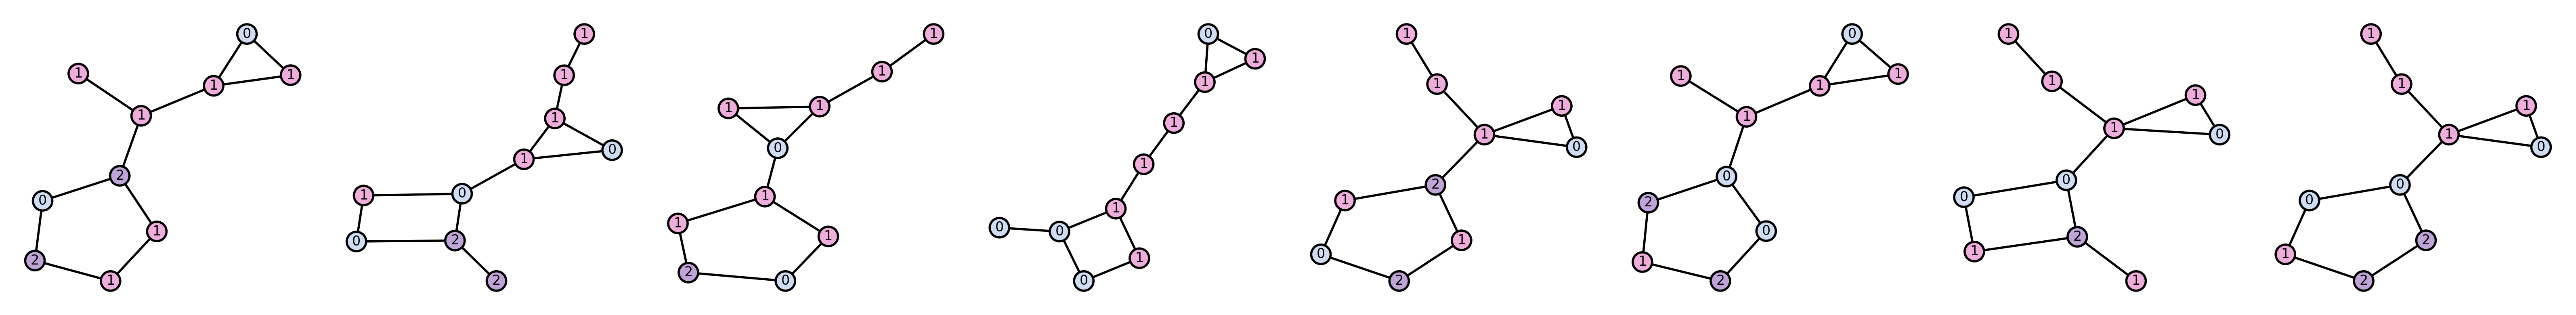

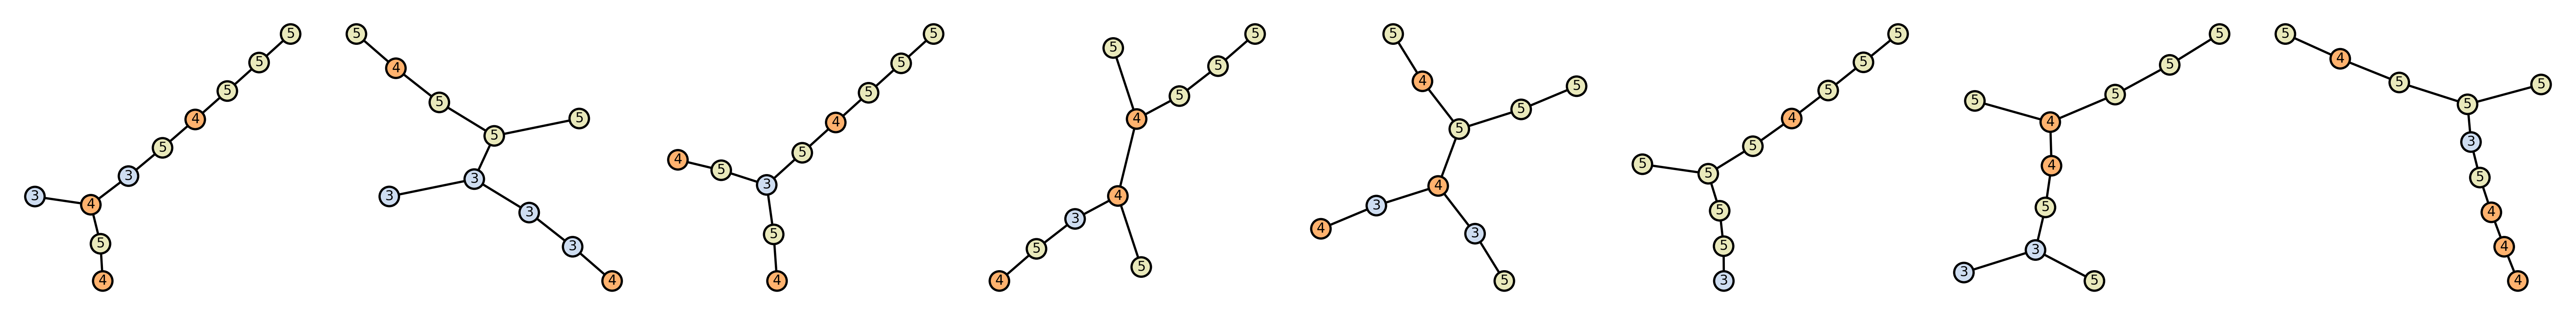

train_graphs:1737   test_graphs:10
CPU times: user 7.9 s, sys: 992 ms, total: 8.89 s
Wall time: 4.78 s


In [35]:
%%time
dataset_size = 2000

if DATASET_TYPE == 'ARTIFICIAL':
    from coco_grape.utils.artificial_graph_constructor import ArtificialGraphDatasetConstructor
    graph_types = ['path', 'tree', 'cycle', 'degree', 'regular', 'dense']
    alphabet_size = 3
    size = 5
    graphs, targets = ArtificialGraphDatasetConstructor(
        graph_generator_target_type_pos='cycle', 
        graph_generator_context_type_pos='cycle', 
        graph_generator_target_type_neg='tree',
        graph_generator_context_type_neg='tree', 
        target_size_pos=size, 
        context_size_pos=size, 
        n_link_edges_pos=1,
        alphabet_size_pos=alphabet_size,
        target_size_neg=size, 
        context_size_neg=size, 
        n_link_edges_neg=1,
        alphabet_size_neg=alphabet_size).sample(dataset_size//2)

    graphs, targets = offset_neg_graphs(graphs, targets, offset=alphabet_size)

    from coco_grape.utils.canonical_order import canonicalise
    #graphs = [canonicalise(graph) for graph in graphs]

    #graph_array = np.empty(len(graphs), dtype=object)
    #for i, graph in enumerate(graphs): graph_array[i] = graph
    #graphs = graph_array
    #haystack = np.unique(make_graph_signature_mtx(graphs),axis=0)
    #print('dataset has %d different templates'%len(haystack))
    print('#graphs:%d'%(len(graphs)))
    
    n_graphs_per_line = 8
    pos_graphs, neg_graphs = select_pos_neg(graphs, targets, n_lines=1, n_graphs_per_line=n_graphs_per_line)
    #plot_sample(graphs, targets, haystack)
    plot_networkx_graphs(pos_graphs, n_cols=n_graphs_per_line)
    plot_networkx_graphs(neg_graphs, n_cols=n_graphs_per_line)
    

elif DATASET_TYPE == 'MOLECULAR':
    from coco_grape.visualizer.mol_display import draw_molecules
    
    from coco_grape.data_loader.mol.mol_loader import PubChemLoader
    assay_ids = ['2631','624249','651741','588350','463230','492952','743219','492992','463213','651610', '630']
    from coco_grape.data_loader.loader import SupervisedDataSetLoader
    assay_id=assay_ids[-4]
    assay_id = '651610'
    def pubchem_loader(): return PubChemLoader().load(assay_id)
    original_graphs, original_targets = SupervisedDataSetLoader(pubchem_loader, size=dataset_size, use_equalized=False).load()
    original_graphs = np.array(original_graphs, dtype=object)
    original_targets = np.array(original_targets)
    print('#graphs:%d   class split:%s'%(len(original_graphs), np.bincount(original_targets)))


    max_node_size = 19
    print('...filter by size <= %d'%max_node_size)
    idxs = [idx for idx, graph in enumerate(original_graphs) if nx.number_of_nodes(graph)<=max_node_size]
    print('#graphs:%d '%(len(idxs)))
    graphs = original_graphs[idxs].tolist()
    targets = original_targets[idxs]

    from coco_grape.visualizer.mol_display import draw_molecules
    draw_molecules(graphs[:7*2])

from sklearn.model_selection import train_test_split
# Assuming `graphs` and `targets` are lists or numpy arrays
train_graphs, test_graphs, train_targets, test_targets = train_test_split(
    graphs, targets, test_size=10, random_state=42  # Adjust test_size as needed
)
print(f'train_graphs:{len(train_graphs)}   test_graphs:{len(test_graphs)}')

---

# Experiment

In [21]:
nbits = 11
verbose = True

---

In [22]:
from coco_grape.module.quotientgraph.display import display, display_mappings, display_decomposition_graph, decomposition_to_graph
from coco_grape.module.quotientgraph.vectorize import QuotientGraphTransformer, QuotientGraphNodeTransformer
from coco_grape.module.quotientgraph.operator import *
def draw(graph, df, nbits):
    display_decomposition_graph(decomposition_to_graph(df))
    qg = QuotientGraph(graph=graph).create_default_image_node().update()
    qg = df(qg)
    qg.update()
    display(qg)
    display_mappings(qg)

df0_list = [compose(combination(distance=(d,d)), node(), prepend_label(label=d)) for d in range(2,10)]
df0 = add(*df0_list)
df1 = add(df0, cycle(), tree(), path(number_of_edges=(1,3)), neighborhood(radius=(0,2)))
df2 = compose(df1, unlabel())
df = add(df1,df2)
#draw(graphs[0], df, nbits)

node_graph_vectorizer = QuotientGraphNodeTransformer(decomposition_function=df, nbits=nbits)
graph_vectorizer = QuotientGraphTransformer(decomposition_function=df, nbits=nbits)

In [41]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import SGDClassifier
from node_diffusion.low_rank_mlp import LowRankMLP

latent_embedding_dimension=128
number_of_transformer_layers=4
transformer_attention_head_count=4
total_steps = 50
learning_rate = 1e-4
maximum_epochs = 2000
batch_size=16
lambda_degree_importance = 1
lambda_node_exist_importance = 1
degree_temperature = 1
lambda_locality_importance = 1


from v_0_1.node_diffusion.conditional_denoising_node_generator import ConditionalNodeGenerator
conditional_node_generator_model = ConditionalNodeGenerator(
    latent_embedding_dimension=latent_embedding_dimension,
    number_of_transformer_layers=number_of_transformer_layers,
    transformer_attention_head_count=transformer_attention_head_count,
    transformer_dropout=.2,
    learning_rate=learning_rate,
    maximum_epochs=maximum_epochs,
    batch_size=batch_size,
    total_steps=total_steps,
    verbose=verbose,
    lambda_degree_importance=lambda_degree_importance,
    lambda_node_exist_importance=lambda_node_exist_importance,
    degree_temperature=degree_temperature,
    lambda_locality_importance=lambda_locality_importance,
    use_guidance=False
)

from node_diffusion.decompositional_encoder_decoder import ConditionalNodeGeneratorModel
conditioning_to_node_embeddings_generator = ConditionalNodeGeneratorModel(
    conditional_node_generator=conditional_node_generator_model, 
    verbose=verbose)

USE_RANDOM_FOREST_CLASSIFIER = True

if USE_RANDOM_FOREST_CLASSIFIER:
    node_label_classifier = RandomForestClassifier(n_estimators=300, n_jobs=-1)
    edge_label_classifier = RandomForestClassifier(n_estimators=300, n_jobs=-1)
    adjacency_matrix_classifier = RandomForestClassifier(n_estimators=300, n_jobs=-1)
else:

    max_epochs = 200
    from node_diffusion.low_rank_mlp import LowRankMLP
    hidden_dim = 32
    node_label_classifier = LowRankMLP(
        hidden_layers=2,
        hidden_dim=hidden_dim,
        thin_size=hidden_dim//3,
        dropout=0.5,
        negative_slope=0.01,
        lr=1e-4,
        max_epochs=max_epochs,
        batch_size=batch_size,
        lr_patience=5,
        task='classification',
        verbose=verbose
    )

    hidden_dim = 16
    edge_label_classifier = LowRankMLP(
        hidden_layers=2,
        hidden_dim=hidden_dim,
        thin_size=hidden_dim//4,
        dropout=0.5,
        negative_slope=0.01,
        lr=1e-4,
        max_epochs=max_epochs,
        batch_size=batch_size,
        lr_patience=5,
        task='classification',
        verbose=verbose
    )

    hidden_dim = 32
    adjacency_matrix_classifier = LowRankMLP(
        hidden_layers=2,
        hidden_dim=hidden_dim,
        thin_size=int(hidden_dim/1.75),
        dropout=0.3,
        negative_slope=0.01,
        lr=1e-4,
        max_epochs=max_epochs,
        batch_size=batch_size,
        lr_patience=5,
        task='classification',
        verbose=verbose
    )

from node_diffusion.decompositional_encoder_decoder import DecompositionalNodeEncoderDecoder
"""
negative_sample_factor           : Ratio for sampling negative locality pairs per positive.
existence_threshold        : Threshold to consider a node existent.
num_augmentation_iterations: Number of augmentation noise iterations.
augmentation_noise         : Maximum noise amplitude for augmentation.
enforce_connectivity       : Whether to enforce a single connected component.
degree_slack_penalty       : Weight applied to slack variables for degree deviations.
warm_start_mst             : Whether to warm start solver using maximum spanning tree.
"""
node_embeddings_to_graph_generator = DecompositionalNodeEncoderDecoder(
    adjacency_matrix_classifier=adjacency_matrix_classifier, 
    node_label_classifier=node_label_classifier,
    edge_label_classifier=edge_label_classifier,
    verbose=verbose,
    negative_sample_factor=2,
    num_augmentation_iterations=1,
    augmentation_noise=1e-1,
    enforce_connectivity=True,
    warm_start_mst=True)

from node_diffusion.decompositional_encoder_decoder import DecompositionalEncoderDecoder
decompositional_encoder_decoder = DecompositionalEncoderDecoder(
    graph_vectorizer=graph_vectorizer,
    node_graph_vectorizer=node_graph_vectorizer, 
    conditioning_to_node_embeddings_generator=conditioning_to_node_embeddings_generator,
    node_embeddings_to_graph_generator=node_embeddings_to_graph_generator,
    use_locality_supervision=True,
    locality_sample_fraction=.1,
    verbose=verbose)

In [ ]:
%%time
decompositional_encoder_decoder.fit(train_graphs, train_conditioning_to_node_embeddings_generator=True, train_node_embeddings_to_graph_generator=True)

Fitting model on 1737 graphs
Node encoding 1737 graphs
Class 'DecompositionalEncoderDecoder', Function 'node_encode' executed in 90.60 seconds (1.51 minutes, 0.03 hours).
Encoding 1737 graphs
Class 'DecompositionalEncoderDecoder', Function 'graph_encode' executed in 87.29 seconds (1.45 minutes, 0.02 hours).
Using edge supervision for training the conditioning to node embeddings generator.
adj_mtx_to_targets: Sampling 27799 edges (10.00%) from 277988 total pairs.
Training conditional model on 1737 graphs with 10 nodes each.
Using edge supervision with 27799 edge pairs.


In [24]:
%%time
if False:
    decompositional_encoder_decoder.fit_classifier(train_graphs, train_targets, epochs=50, lr=1e-4)

CPU times: user 4 μs, sys: 1 μs, total: 5 μs
Wall time: 8.11 μs


In [25]:
if False:
    decompositional_encoder_decoder.toggle_verbose()
    sampled_graphs = decompositional_encoder_decoder.sample_from(graphs, 7)
    plot_networkx_graphs(sampled_graphs, n_cols=len(sampled_graphs))

# Outputs

In [ ]:
print('true graphs')
import random
n_samples = 7
probe_train_graphs = random.sample(train_graphs, min(n_samples, len(train_graphs)))
plot_networkx_graphs(probe_train_graphs)

#encodings_list contains the true node encodings
node_encodings_list, conditioning_encodings = decompositional_encoder_decoder.encode(probe_train_graphs)

print('decode starting from the true node encodings')
decoded_graphs = decompositional_encoder_decoder.node_embeddings_to_graph_generator.decode(node_encodings_list)
plot_networkx_graphs(decoded_graphs)

print('decode starting from the true graph encodings i.e. the sum of the true node encodings')
conditioning_decoded_graphs = decompositional_encoder_decoder.decode(conditioning_encodings)
plot_networkx_graphs(conditioning_decoded_graphs)

plot_label_comparative_histogram(probe_train_graphs,decoded_graphs,conditioning_decoded_graphs)

In [ ]:
if True:
    print('true graphs')
    probe_train_graphs = random.sample(train_graphs, min(n_samples, len(train_graphs)))
    plot_networkx_graphs(probe_train_graphs)

    #encodings_list contains the true node encodings
    node_encodings_list, conditioning_encodings = decompositional_encoder_decoder.encode(probe_train_graphs)

    print('decode starting from the true node encodings with noise')

    for eps in np.linspace(0.0,0.7,4):
        print('-'*100)
        print(f'eps:{eps:.3f}')
        perturbed_node_encodings_list = [node_encodings+np.random.rand(*node_encodings.shape)*eps for node_encodings in node_encodings_list]
        decoded_graphs = decompositional_encoder_decoder.node_embeddings_to_graph_generator.decode(perturbed_node_encodings_list)
        plot_networkx_graphs(decoded_graphs)

Node encoding 40 graphs
Class 'DecompositionalEncoderDecoder', Function 'node_encode' executed in 7.79 seconds (0.13 minutes, 0.00 hours).
Encoding 40 graphs
Class 'DecompositionalEncoderDecoder', Function 'graph_encode' executed in 0.99 seconds (0.02 minutes, 0.00 hours).
Check: a high correlation score would indicate that the node embeddings once summed up generate the same graph encoding that was used in input to condition their generation
Predicting node matrices for 40 graphs...
Predicting node matrices for 40 graphs...
Applied head-based projection for existence/degree channels.
Class 'ConditionalNodeGeneratorModel', Function 'predict' executed in 2.25 seconds (0.04 minutes, 0.00 hours).


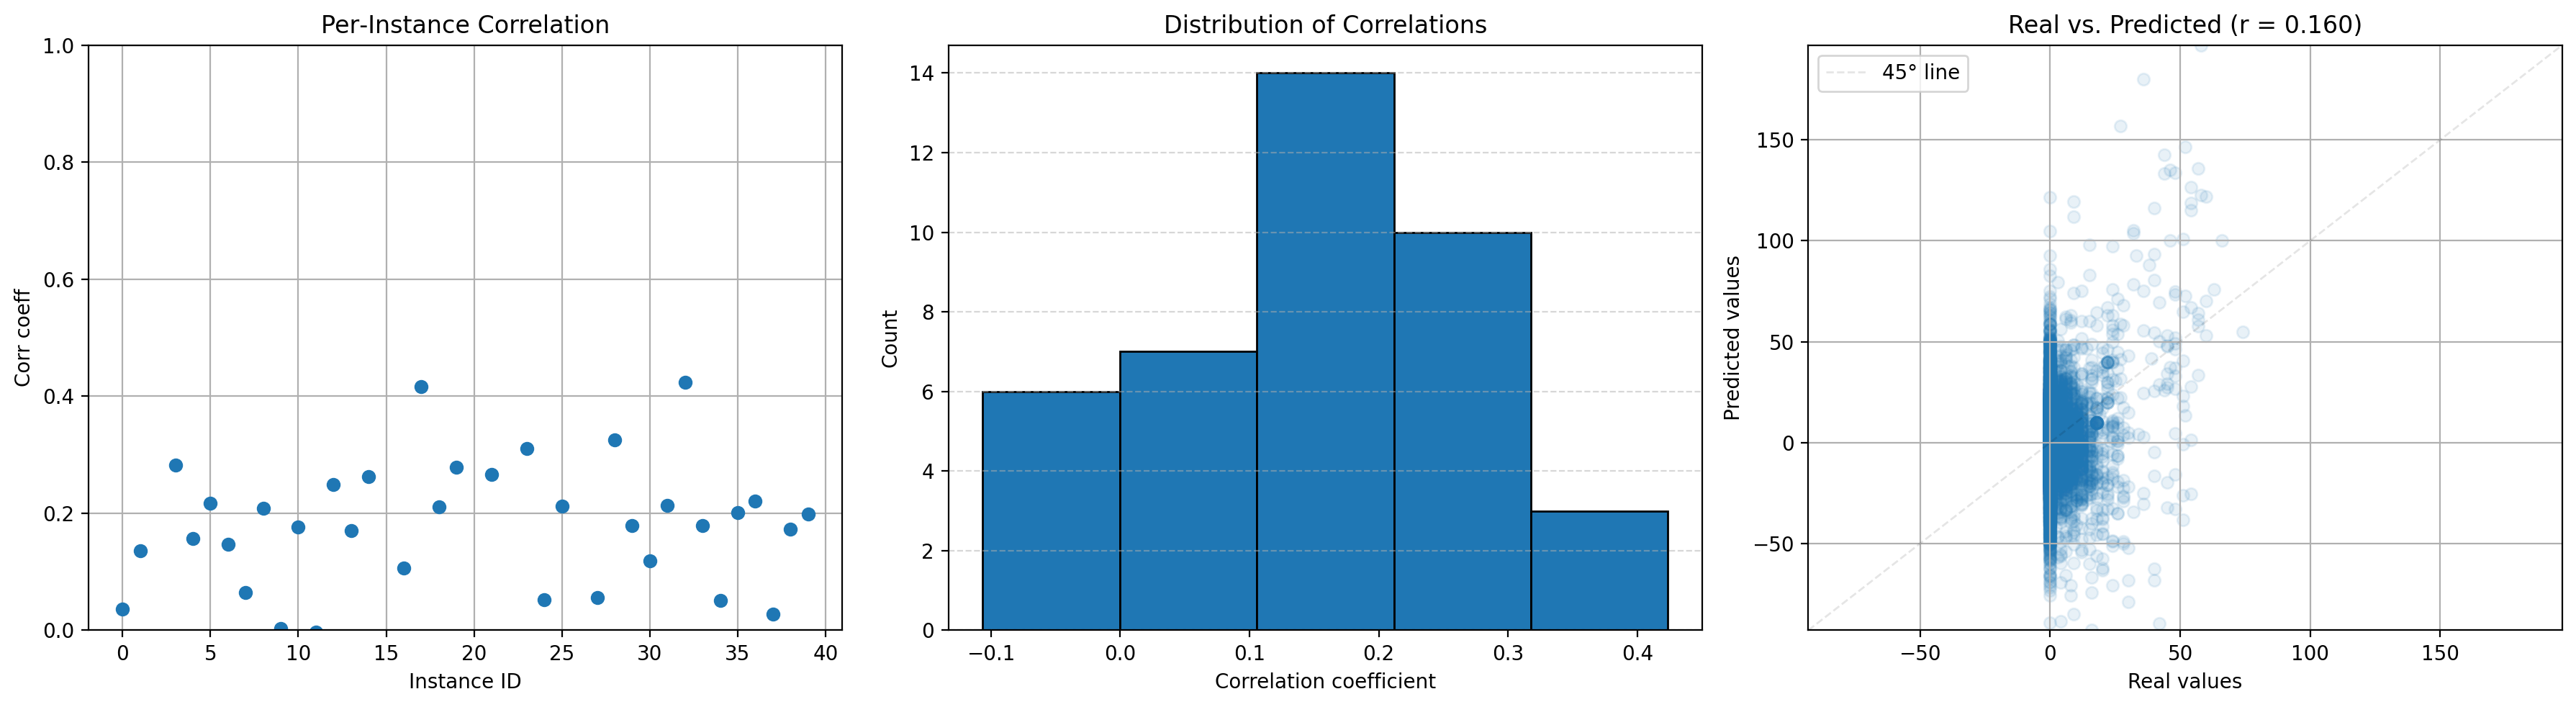

In [33]:
import numpy as np
import matplotlib.pyplot as plt
import random

# Sample a subset of training graphs
n_samples = 40
probe_train_graphs = random.sample(train_graphs, min(n_samples, len(train_graphs)))

# Encode graphs to get node and conditioning encodings
node_encodings_list, conditioning_encodings = decompositional_encoder_decoder.encode(probe_train_graphs)

print('Check: a high correlation score would indicate that the node embeddings once summed up generate the same graph encoding that was used in input to condition their generation')

# Predict node encodings from conditioning encodings
predicted_node_encodings_list = decompositional_encoder_decoder.conditioning_to_node_embeddings_generator.predict(conditioning_encodings)

# Compute per‐instance correlation coefficients
ccs = []
for i in range(len(conditioning_encodings)):
    pred = predicted_node_encodings_list[i].sum(axis=0)
    real = conditioning_encodings[i]
    ccs.append(np.corrcoef(real, pred)[0, 1])

# Also assemble the full arrays for an overall scatter
data_pred_list = [predicted_node_encodings_list[i].sum(axis=0) for i in range(len(conditioning_encodings))]
data_real_list = [conditioning_encodings[i] for i in range(len(conditioning_encodings))]

data_pred = np.hstack(data_pred_list)
data_real = np.hstack(data_real_list)

# Compute overall Pearson correlation
overall_corr = np.corrcoef(data_real, data_pred)[0, 1]

# Determine joint plotting limits for the 45° line
min_val = min(data_real.min(), data_pred.min())
max_val = max(data_real.max(), data_pred.max())
lims = [min_val, max_val]

# Create a row of 3 subplots
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

# 1) Left: scatter of per‐instance correlation
ax1.plot(ccs, 'o')
ax1.set_ylim(0, 1)
ax1.set_xlabel('Instance ID')
ax1.set_ylabel('Corr coeff')
ax1.set_title('Per‐Instance Correlation')
ax1.grid(True)

# 2) Middle: histogram of correlation values
ax2.hist(ccs, bins=5, edgecolor='black')
ax2.set_xlabel('Correlation coefficient')
ax2.set_ylabel('Count')
ax2.set_title('Distribution of Correlations')
ax2.grid(axis='y', linestyle='--', alpha=0.5)

# 3) Right: overall scatter with 45° line and correlation in title
ax3.scatter(data_real, data_pred, alpha=0.1)
ax3.plot(lims, lims, 'k--', linewidth=1, alpha=0.1, label='45° line')
ax3.set_xlim(lims)
ax3.set_ylim(lims)
ax3.set_xlabel("Real values")
ax3.set_ylabel("Predicted values")
ax3.set_title(f"Real vs. Predicted (r = {overall_corr:.3f})")
ax3.legend(loc='upper left')
ax3.grid(True)

plt.tight_layout()
plt.show()


True degrees
[1 3 1 3 1 1 3 2 2 1]
[1 3 1 3 1 1 3 1 3 1]
[1 4 1 2 1 1 3 1 2 2]
[2 4 1 2 2 2 3 2 2 2]
[1 3 1 2 2 2 2 1 2 2]
[2 4 1 2 2 3 2 2 2 2]
[2 3 1 2 1 1 3 2 2 1]
[1 3 1 3 1 2 2 2 2 1]
[3 3 1 2 2 2 3 2 2 2]
[2 3 1 2 1 1 3 1 2 2]
[1 4 1 2 1 2 3 1 1 2]
[2 3 1 2 1 2 3 1 2 1]
[2 4 1 2 2 2 4 3 2 2]
[2 3 2 2 2 2 3 2 2 2]
[3 3 1 2 2 2 4 1 2 2]
[1 3 1 2 2 1 4 1 2 1]
[1 3 2 2 1 2 2 2 2 1]
[2 4 1 2 2 2 2 3 2 2]
[1 4 1 2 1 1 2 2 3 1]
[2 4 1 2 2 2 3 2 2 2]
[1 3 1 3 1 1 4 2 1 1]
[2 4 1 2 2 2 2 3 3 1]
[1 4 1 2 1 1 2 3 2 1]
[2 3 1 3 2 3 4 2 2 2]
[2 3 1 2 1 1 3 1 2 2]
[2 3 1 3 2 3 2 2 3 1]
[1 3 1 3 1 2 2 3 1 1]
[1 3 1 3 1 1 2 1 2 3]
[2 3 1 2 3 1 2 3 3 2]
[1 3 2 2 1 1 3 2 2 1]
[2 3 1 2 3 2 3 3 2 1]
[1 3 1 3 1 1 2 2 2 2]
[3 3 1 2 2 2 2 2 3 2]
[2 3 1 3 2 1 4 2 2 2]
[1 4 1 2 1 1 2 1 4 1]
[2 3 2 2 2 2 3 2 2 2]
[2 3 1 2 1 1 3 1 2 2]
[2 3 1 3 2 2 2 2 3 2]
[2 3 1 2 3 2 2 2 3 2]
[1 3 1 3 1 1 4 1 2 1]

Predicted degrees
[1 1 1 1 1 1 1 1 1 1]
[1 1 1 1 1 1 1 1 1 1]
[1 1 1 1 1 4 1 1 1 4]
[4 4 4 4 4 4 4 4 4 4]


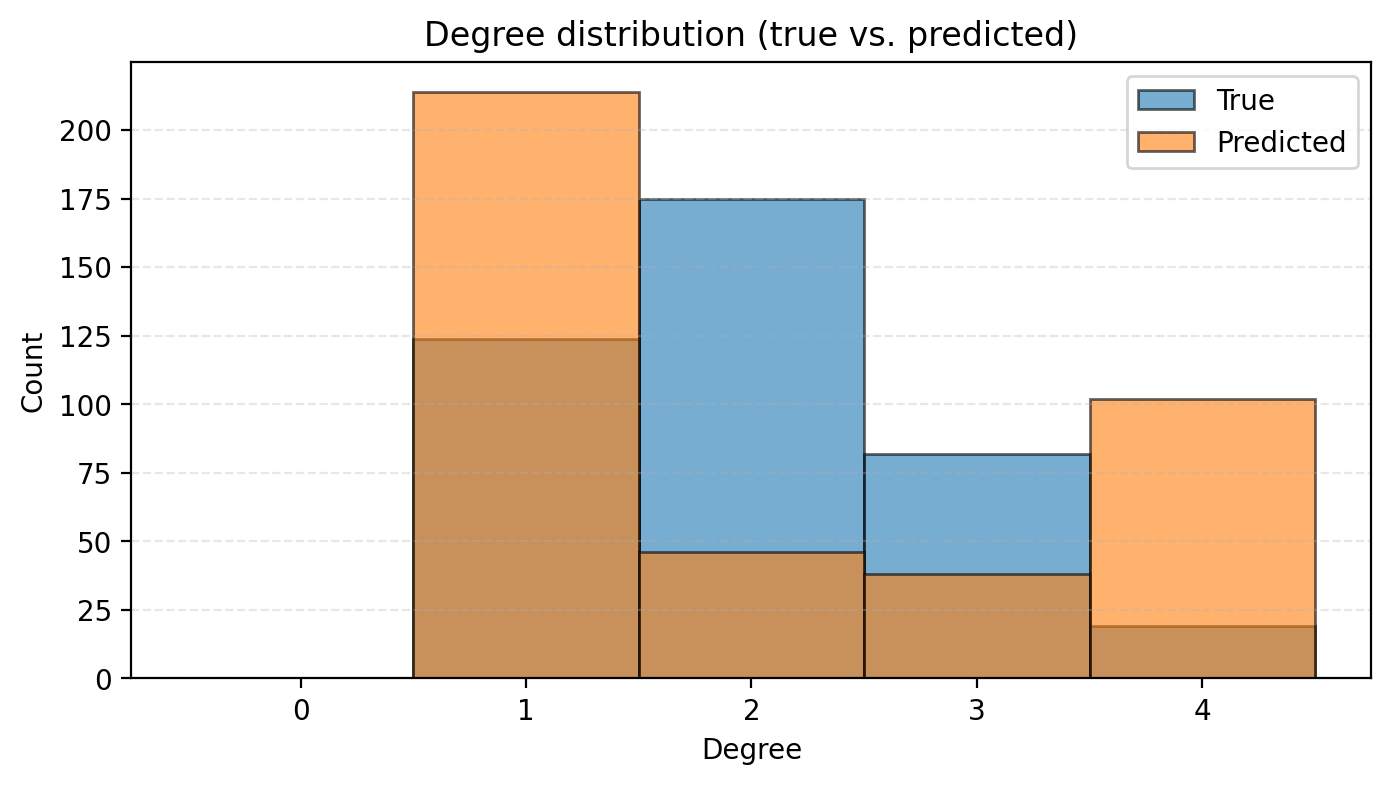

In [34]:
print('True degrees')
for node_encodings in node_encodings_list:
    print(node_encodings[:,1].astype(int))


print()
print('Predicted degrees')
for node_encodings in predicted_node_encodings_list:
    # build mask where the “presence” flag (col 0) is non‐zero
    mask = node_encodings[:, 0] > 0.5
    
    # apply it to col 1, round & cast to int
    degs = np.rint(node_encodings[mask, 1]).astype(int)
    
    print(degs)
    
print()
print('Predicted degrees (full)')
print(np.rint(np.array([node_encodings[:,1] for node_encodings in predicted_node_encodings_list])).astype(int))
print(np.rint(np.array([node_encodings[:,0] for node_encodings in predicted_node_encodings_list])).astype(int))

compare_degree_histograms(node_encodings_list, predicted_node_encodings_list)
plt.show()

true graphs


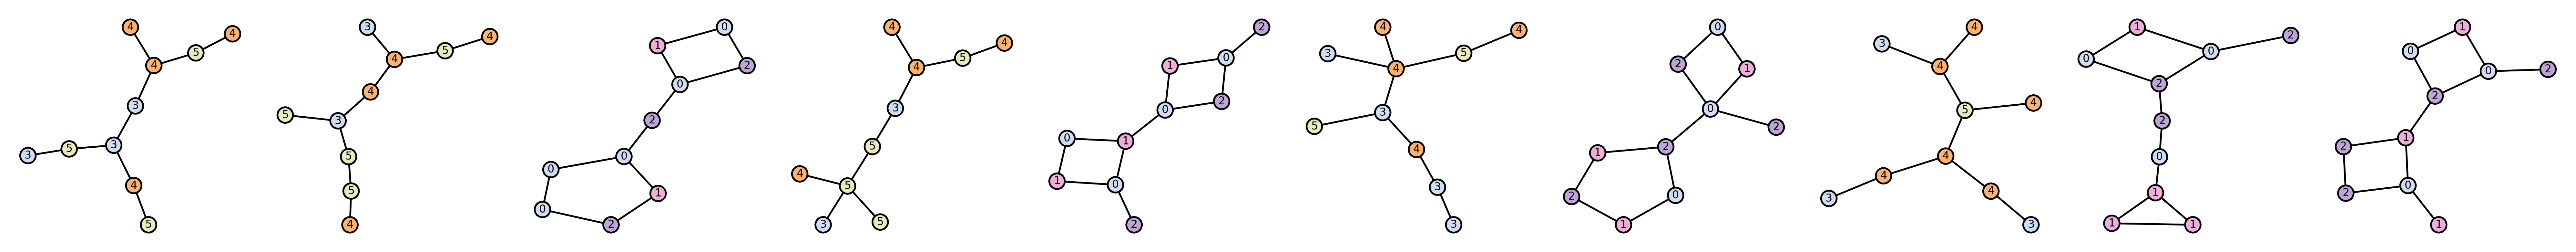

Node encoding 10 graphs
Class 'DecompositionalEncoderDecoder', Function 'node_encode' executed in 4.48 seconds (0.07 minutes, 0.00 hours).
Encoding 10 graphs
Class 'DecompositionalEncoderDecoder', Function 'graph_encode' executed in 2.71 seconds (0.05 minutes, 0.00 hours).
decode starting from the true node encodings
Class 'DecompositionalNodeEncoderDecoder', Function 'decode' executed in 2.04 seconds (0.03 minutes, 0.00 hours).


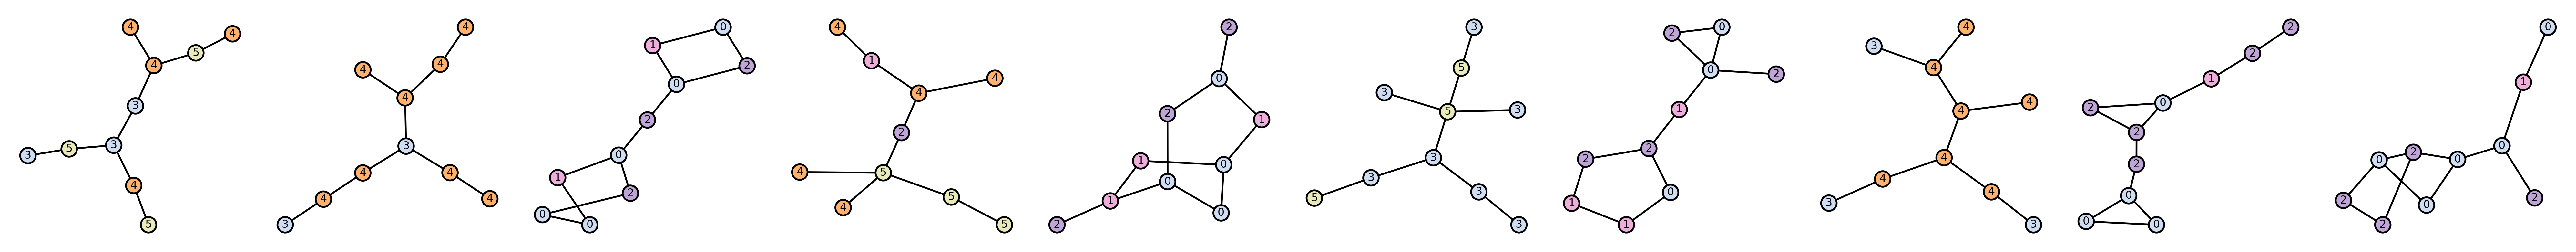

decode starting from the true graph encodings i.e. the sum of the true node encodings
Decoding 10 conditioning vectors
Predicting node matrices for 10 graphs...
Predicting node matrices for 10 graphs...
Applied head-based projection for existence/degree channels.
Class 'ConditionalNodeGeneratorModel', Function 'predict' executed in 0.90 seconds (0.02 minutes, 0.00 hours).
Class 'DecompositionalNodeEncoderDecoder', Function 'decode' executed in 310.49 seconds (5.17 minutes, 0.09 hours).


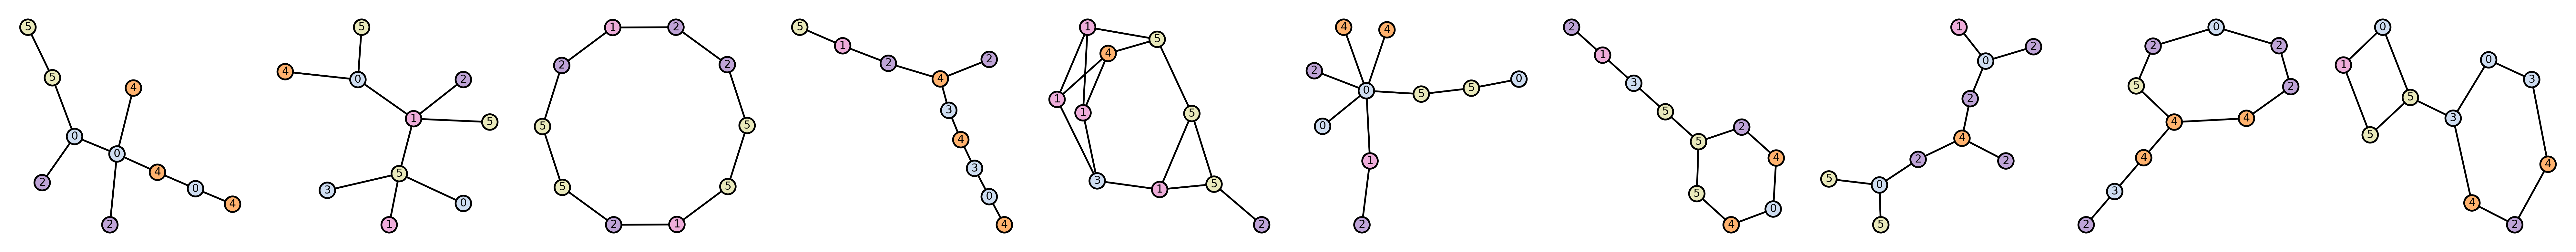

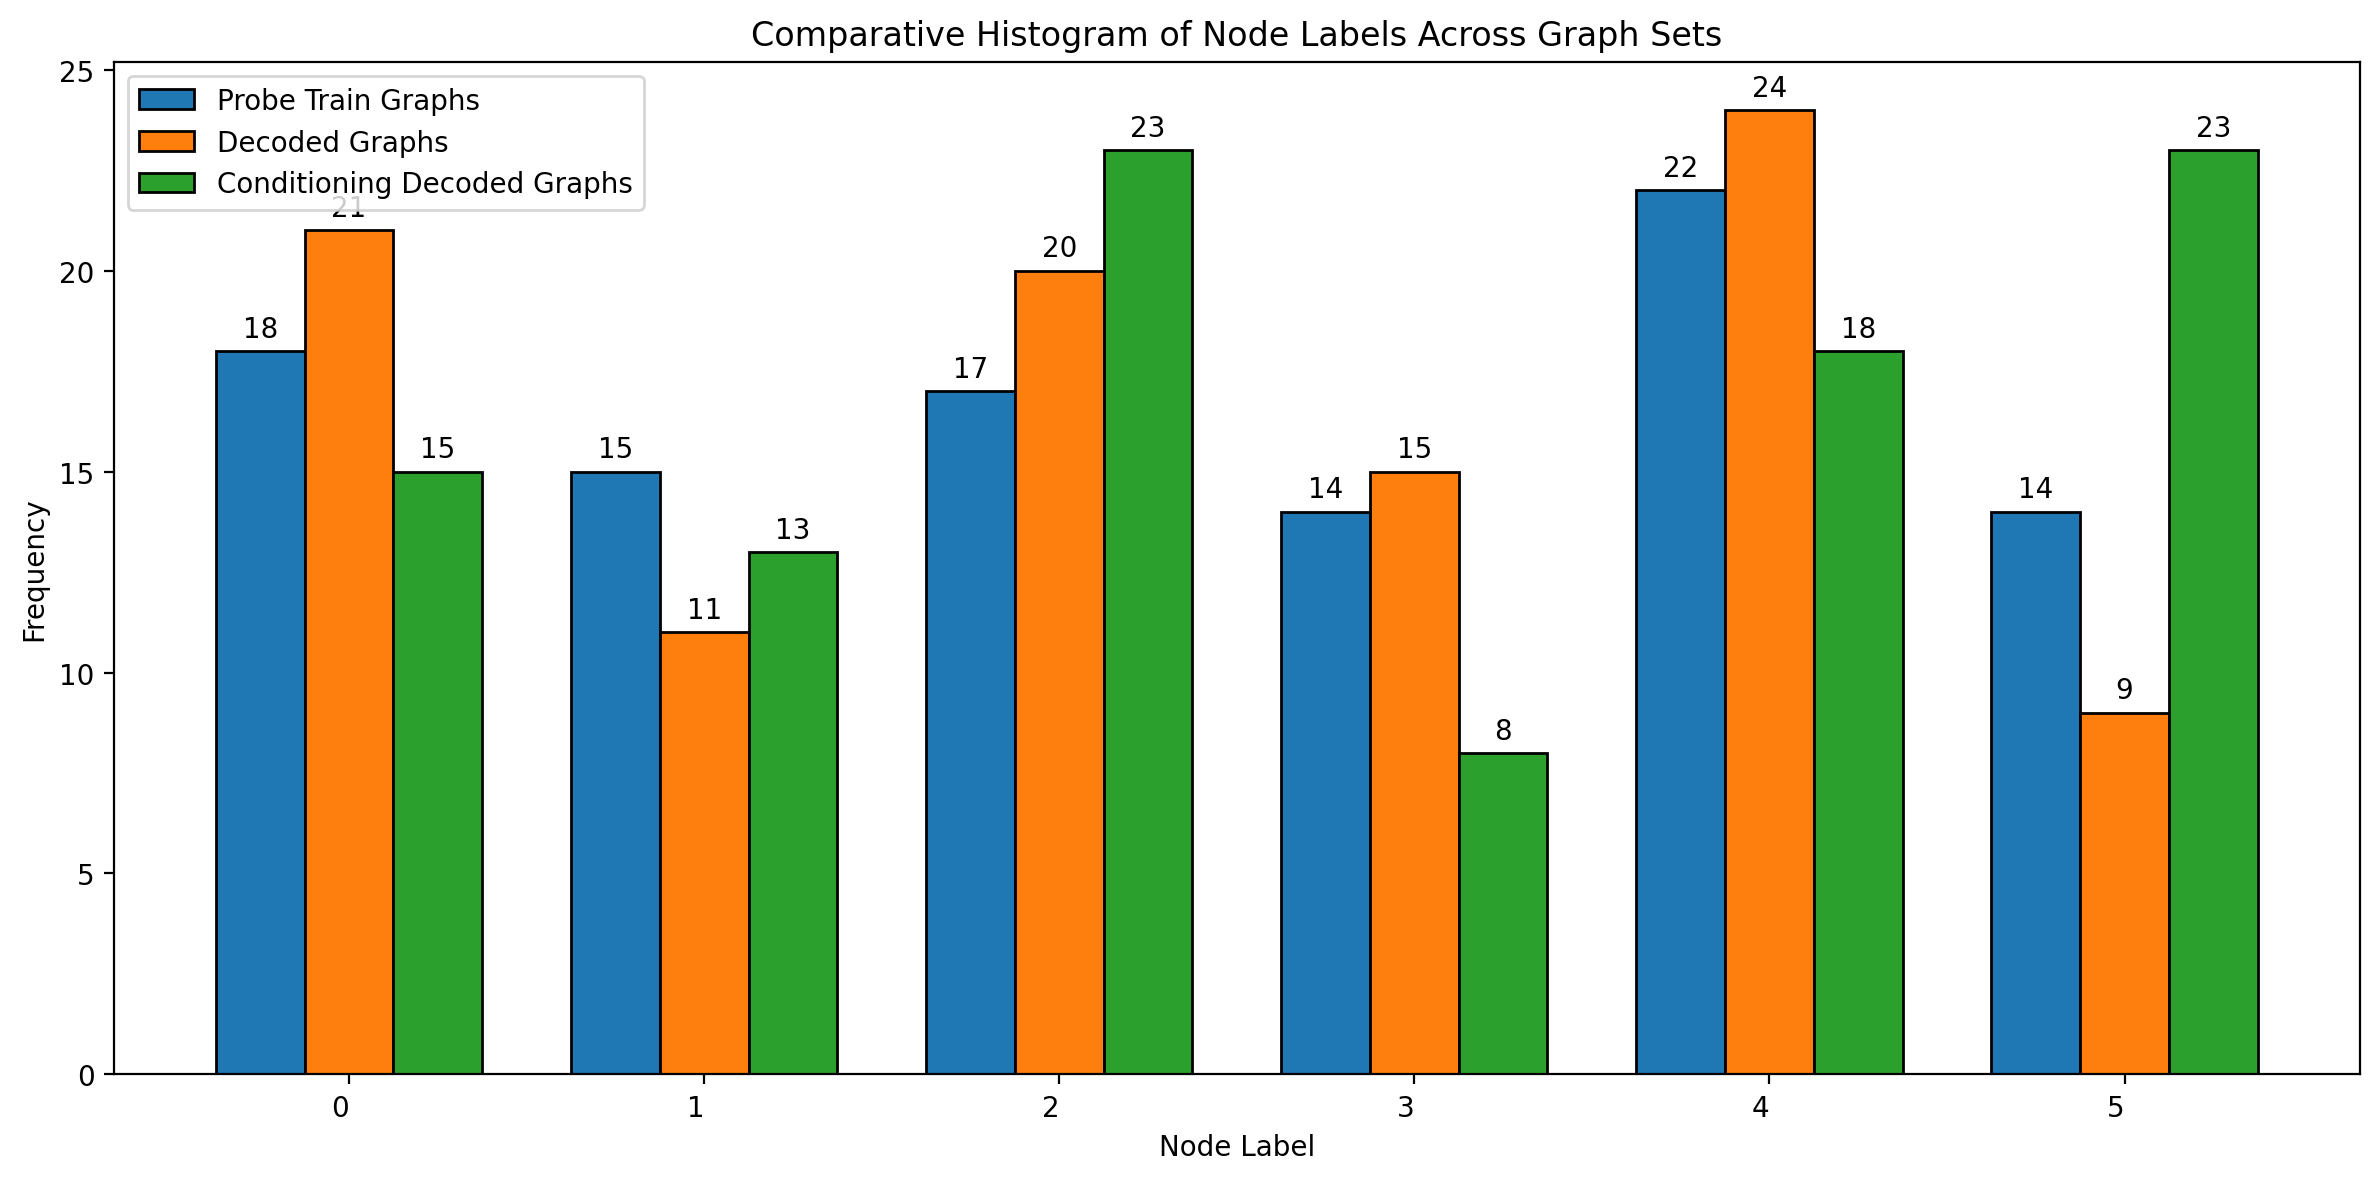

In [30]:
print('true graphs')
probe_test_graphs = random.sample(test_graphs, min(n_samples, len(test_graphs)))
plot_networkx_graphs(probe_test_graphs)

#encodings_list contains the true node encodings
node_encodings_list, conditioning_encodings = decompositional_encoder_decoder.encode(probe_test_graphs)

print('decode starting from the true node encodings')
decoded_graphs = decompositional_encoder_decoder.node_embeddings_to_graph_generator.decode(node_encodings_list)
plot_networkx_graphs(decoded_graphs)

print('decode starting from the true graph encodings i.e. the sum of the true node encodings')
conditioning_decoded_graphs = decompositional_encoder_decoder.decode(conditioning_encodings)
plot_networkx_graphs(conditioning_decoded_graphs)

plot_label_comparative_histogram(probe_test_graphs,decoded_graphs,conditioning_decoded_graphs)

---

In [ ]:
decompositional_encoder_decoder.toggle_verbose()

In [ ]:
n_samples = 9

In [ ]:
%%time
sampled_graphs = decompositional_encoder_decoder.sample_from(graphs, n_samples)
plot_networkx_graphs(sampled_graphs, n_cols=len(sampled_graphs))

In [ ]:
neg_graphs = [graph for graph, target in zip(graphs, targets) if target==0]
pos_graphs = [graph for graph, target in zip(graphs, targets) if target!=0]

In [ ]:
%%time
sampled_graphs = decompositional_encoder_decoder.sample_from(pos_graphs, n_samples)
plot_networkx_graphs(sampled_graphs, n_cols=len(sampled_graphs))

In [ ]:
%%time
sampled_graphs = decompositional_encoder_decoder.sample_from(neg_graphs, n_samples)
plot_networkx_graphs(sampled_graphs, n_cols=len(sampled_graphs))

---

In [ ]:
decompositional_encoder_decoder.toggle_verbose()

In [ ]:
import random

# Pick two random graphs from your dataset
G1, G2 = random.sample(graphs, 2)
print(f"\nInterpolating between graph #{graphs.index(G1)} and graph #{graphs.index(G2)}...")
plot_networkx_graphs([G1,G2], n_cols=10)

In [ ]:
%%time

print("\nInterpolated graphs")

similarities_to_first_list = []
similarities_to_last_list = []
n_iter = 5
for it in range(n_iter):
    print('_'*100)
    print(f'{it+1}/{n_iter}')
    # Perform interpolation (e.g. 10 steps) in the global embedding space
    interpolated_graphs = decompositional_encoder_decoder.interpolate(
        G1, G2,
        n_steps=7,
        t_start=0.0,
        t_end=1.0
    )
    # Plot them in a grid (2 rows × 5 cols)
    #all_graphs = [G1]+interpolated_graphs+[G2]
    all_graphs = interpolated_graphs
    plot_networkx_graphs(all_graphs, n_cols=len(all_graphs))
    similarities_to_first, similarities_to_last = plot_similarities(all_graphs, G1, G2, graph_vectorizer)
    similarities_to_first_list.append(similarities_to_first)
    similarities_to_last_list.append(similarities_to_last)
    
plot_two_iqr_medians(similarities_to_first_list, similarities_to_last_list, 'similarities_to_first', 'similarities_to_last')

In [ ]:
if False:
    distances_to_first = compute_graph_edit_distances(G1, all_graphs)
    print(distances_to_first)
    distances_to_last = compute_graph_edit_distances(G2, all_graphs)
    print(distances_to_last)

---

In [ ]:
%%time
import random

# 1) Select a random subset of graphs from your dataset
subset_size = 2
subset = random.sample(graphs, subset_size)
indices = [graphs.index(G) for G in subset]

print(f"\nComputing prototypes for graphs #{indices}…")
#plot_networkx_graphs(subset, n_cols=subset_size)

# 2) Compute the “centroid” graph in global‐embedding space
print("\nDecoding centroid")
mean_graph = decompositional_encoder_decoder.mean(subset)
all_graphs = subset+[mean_graph]
plot_networkx_graphs(all_graphs, n_cols=len(all_graphs))

---

In [ ]:
%%time
import random

n_samples=7*3
subset_size = 1

conditioning_graphs = random.sample(graphs, subset_size)
plot_networkx_graphs(conditioning_graphs, n_cols=subset_size)

reconstructed_graphs_list = decompositional_encoder_decoder.conditional_sample(conditioning_graphs, n_samples=n_samples)
for conditioning_graph, reconstructed_graphs in zip(conditioning_graphs, reconstructed_graphs_list):
    sorted_reconstructed_graphs = sort_graphs_by_similarity(reconstructed_graphs, [conditioning_graph])
    plot_networkx_graphs(sorted_reconstructed_graphs, n_cols=len(sorted_reconstructed_graphs)//3)

---

In [ ]:
X = decompositional_encoder_decoder.graph_vectorizer.transform(graphs)
y = np.array(targets)
for C in [1e-3, 1e-2, 1e-1, 1, 1e1, 1e2, 1e3]:
    pairs = find_margin_sv_pairs(X, y, C=C)
    print(f"Found {len(pairs)} pairs for C:{C}")

In [ ]:
%%time
new_graphs, new_targets = binary_classification_dataset_generation(
    graphs, 
    targets, 
    decompositional_encoder_decoder,
    n_instances=24,
    C=10,
    creativity=0.1,
    verbose=True)

sorted_new_graphs, sorted_new_targets = importance_sorting(new_graphs,new_targets, graphs, targets, decompositional_encoder_decoder, n_bootstrap=10, C=1.0)
plot_networkx_graphs(sorted_new_graphs, n_cols=8)

In [ ]:
%%time
creative_new_graphs, creative_new_targets = binary_classification_dataset_generation(
    graphs, 
    targets, 
    decompositional_encoder_decoder,
    n_instances=24,
    C=0.1,
    creativity=0.9,
    verbose=True)
sorted_creative_new_graphs, sorted_creative_new_targets = importance_sorting(creative_new_graphs,creative_new_targets, graphs, targets, decompositional_encoder_decoder, n_bootstrap=10, C=1.0)
plot_networkx_graphs(sorted_creative_new_graphs, n_cols=8)

In [ ]:
%%time
all_creative_new_graphs = creative_new_graphs + new_graphs
all_creative_new_targets = np.array(list(creative_new_targets) + list(new_targets))
sorted_all_creative_new_graphs, sorted_all_creative_new_targets = importance_sorting(all_creative_new_graphs,all_creative_new_targets, graphs, targets, decompositional_encoder_decoder, n_bootstrap=10, C=1.0)
plot_networkx_graphs(sorted_all_creative_new_graphs, n_cols=8)

---